# Reproduction of "A Dual Coordinate Descent Method for Large-scale Linear SVM"

This notebook implements the dual coordinate descent (DCD) method for linear SVM as described in:

> Cho-Jui Hsieh, Kai-Wei Chang, Chih-Jen Lin, S. Sathiya Keerthi, S. Sundararajan,
> **"A Dual Coordinate Descent Method for Large-scale Linear SVM"**, ICML 2008.

We train on the RCV1 dataset and compare DCD with standard linear SVM solvers.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_rcv1
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

## Load RCV1 data

The paper uses RCV1 among other large sparse text datasets. Here we fetch RCV1 from scikit-learn and construct a binary classification task using one label column.

In [2]:
print("Loading RCV1 (this may take a while the first time)...")

data = fetch_rcv1()

X = data.data  # sparse CSR matrix
# Use first label column and map {0,1} -> {-1, +1}
y = data.target[:, 0].toarray().ravel().astype(np.int8)
y[y == 0] = -1

print("Full dataset shape:", X.shape)

Loading RCV1 (this may take a while the first time)...
Full dataset shape: (804414, 47236)


## Train / test split

We optionally subsample to keep runtime reasonable in this environment, then use a stratified 4/5–1/5 split as in the paper.

In [3]:
# Use full RCV1 dataset as in the paper (677,399 instances).
# Set sample_size to an integer if you want to subsample for quicker experiments.
sample_size = None
if sample_size is not None and sample_size < X.shape[0]:
    X = X[:sample_size]
    y = y[:sample_size]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (643531, 47236)
Test size: (160883, 47236)


## Dual Coordinate Descent SVM implementation

We now implement the dual coordinate descent algorithm (Algorithm 1 with random permutation of coordinates) for both L1- and L2-loss linear SVM, without a bias term, as in the experimental section of the paper.

In [4]:
class DCDSVM:
    """Dual coordinate descent for linear SVM (L1 or L2 loss).\n

    This follows Algorithm 1 (with random permutation of coordinates) from\n
    "A Dual Coordinate Descent Method for Large-scale Linear SVM"\n
    by Hsieh et al. (ICML 2008).
    """

    def __init__(
        self,
        C=1.0,
        loss="l2",
        epochs=1,
        tol=None,
        record_objective=False,
        record_every=2000,
    ):
        self.C = C
        self.loss = loss  # "l1" or "l2"
        self.epochs = epochs
        self.tol = tol
        self.record_objective = record_objective
        self.record_every = record_every

        self.w = None
        self.alpha_ = None
        self.obj_history_ = []
        self.time_history_ = []

    def _setup_D_and_U(self, n_samples):
        """Set diagonal D and box constraint U according to the loss."""
        if self.loss == "l1":
            # L1-SVM: U = C, Dii = 0
            D = np.zeros(n_samples, dtype=float)
            U = self.C
        elif self.loss == "l2":
            # L2-SVM: U = +inf, Dii = 1/(2C)
            D = np.full(n_samples, 1.0 / (2.0 * self.C), dtype=float)
            U = np.inf
        else:
            raise ValueError("loss must be 'l1' or 'l2'")
        return D, U

    def fit(self, X, y):
        n_samples, n_features = X.shape

        alpha = np.zeros(n_samples, dtype=float)
        w = np.zeros(n_features, dtype=float)

        D, U = self._setup_D_and_U(n_samples)

        # Precompute Qii_bar = ||xi||^2 + Dii
        Qii_bar = np.array(X.multiply(X).sum(axis=1)).ravel() + D

        # reset histories
        self.obj_history_ = []
        self.time_history_ = []

        start_time = time.time()
        updates = 0

        # initial point at time 0
        if self.record_objective:
            obj0 = primal_objective(w, X, y, C=self.C, loss=self.loss)
            self.obj_history_.append(obj0)
            self.time_history_.append(0.0)

        for epoch in range(self.epochs):
            print("Epoch:", epoch + 1)

            # Random permutation of coordinates (Section 3.1)
            for i in np.random.permutation(n_samples):
                # keep xi as sparse row for the dot, only densify if we update w
                xi_sparse = X[i]

                # Gradient component: G = yi w^T xi - 1 + Dii * alpha_i (Eq. 12)
                G = y[i] * float(xi_sparse.dot(w)) - 1.0 + D[i] * alpha[i]

                if Qii_bar[i] == 0.0:
                    # Degenerate case: xi = 0 for L1-SVM, push alpha to U
                    if U < np.inf:
                        alpha_new = U
                    else:
                        alpha_new = alpha[i]
                else:
                    # Closed-form solution of 1-D quadratic subproblem (Eq. 9)
                    alpha_new = alpha[i] - G / Qii_bar[i]

                    # Project onto box [0, U] (for L1) or [0, +inf) (for L2)
                    if U < np.inf:
                        alpha_new = min(max(alpha_new, 0.0), U)
                    else:
                        alpha_new = max(alpha_new, 0.0)

                if alpha_new != alpha[i]:
                    delta = alpha_new - alpha[i]
                    alpha[i] = alpha_new
                    # Only densify xi when we actually need to update w
                    xi = xi_sparse.toarray().ravel()
                    w += delta * y[i] * xi

                updates += 1

                # record along inner iterations
                if self.record_objective and self.record_every > 0:
                    if updates % self.record_every == 0:
                        obj = primal_objective(w, X, y, C=self.C, loss=self.loss)
                        self.obj_history_.append(obj)
                        self.time_history_.append(time.time() - start_time)

        # final point
        if self.record_objective:
            obj = primal_objective(w, X, y, C=self.C, loss=self.loss)
            self.obj_history_.append(obj)
            self.time_history_.append(time.time() - start_time)

        self.w = w
        self.alpha_ = alpha
        return self

    def decision_function(self, X):
        return X.dot(self.w)

    def predict(self, X):
        scores = self.decision_function(X)
        return np.sign(scores)

## Primal objective helper

We use the primal objective value (Eq. (1) in the paper) to compare convergence between solvers, as done in Section 5.

In [5]:
def primal_objective(w, X, y, C=1.0, loss="l2"):
    """Compute primal objective (Eq. (1)) for L1 or L2 loss."""
    margins = 1.0 - y * X.dot(w)
    if loss == "l1":
        losses = np.maximum(margins, 0.0)
    elif loss == "l2":
        losses = np.maximum(margins, 0.0) ** 2
    else:
        raise ValueError("loss must be 'l1' or 'l2'")
    return 0.5 * np.dot(w, w) + C * losses.sum()

## Train DCD for L2- and L1-loss SVM

We now train DCD on the training set and evaluate accuracy and primal objective on the training data.

In [6]:
C_value = 1.0
epochs = 1  # we now log within the epoch via record_every

print("=== DCD L2-SVM ===")
dcd_l2 = DCDSVM(C=C_value, loss="l2", epochs=epochs, record_objective=True, record_every=2000)
start = time.time()
dcd_l2.fit(X_train, y_train)
t_dcd_l2 = time.time() - start
pred_l2 = dcd_l2.predict(X_test)
acc_l2 = accuracy_score(y_test, pred_l2)
obj_l2 = primal_objective(dcd_l2.w, X_train, y_train, C=C_value, loss="l2")
print("Training time (s):", t_dcd_l2)
print("Test accuracy:", acc_l2)
print("Train primal objective:", obj_l2)

print("\n=== DCD L1-SVM ===")
dcd_l1 = DCDSVM(C=C_value, loss="l1", epochs=epochs, record_objective=True, record_every=2000)
start = time.time()
dcd_l1.fit(X_train, y_train)
t_dcd_l1 = time.time() - start
pred_l1 = dcd_l1.predict(X_test)
acc_l1 = accuracy_score(y_test, pred_l1)
obj_l1 = primal_objective(dcd_l1.w, X_train, y_train, C=C_value, loss="l1")
print("Training time (s):", t_dcd_l1)
print("Test accuracy:", acc_l1)
print("Train primal objective:", obj_l1)

=== DCD L2-SVM ===
Epoch: 1


/var/folders/j3/c1ymhtkd4gx28tsdpgsc1x140000gn/T/ipykernel_44533/3120286661.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G = y[i] * float(xi_sparse.dot(w)) - 1.0 + D[i] * alpha[i]


Training time (s): 86.39784908294678
Test accuracy: 0.9687536905701659
Train primal objective: 62034.45780199174

=== DCD L1-SVM ===
Epoch: 1


/var/folders/j3/c1ymhtkd4gx28tsdpgsc1x140000gn/T/ipykernel_44533/3120286661.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G = y[i] * float(xi_sparse.dot(w)) - 1.0 + D[i] * alpha[i]


Training time (s): 88.56010007858276
Test accuracy: 0.9721598925927537
Train primal objective: 43777.63972250165


## Baseline solvers: LinearSVC and SGD (hinge)

We compare our DCD implementation with scikit-learn's `LinearSVC` (similar in spirit to LIBLINEAR/TRON in the paper) and `SGDClassifier` with hinge loss (Pegasos-like).

In [7]:
print("=== LinearSVC (squared hinge, no bias) ===")
svc = LinearSVC(C=C_value, loss="squared_hinge", fit_intercept=False)
start = time.time()
svc.fit(X_train, y_train)
t_svc = time.time() - start
pred_svc = svc.predict(X_test)
acc_svc = accuracy_score(y_test, pred_svc)
w_svc = svc.coef_.ravel()
obj_svc = primal_objective(w_svc, X_train, y_train, C=C_value, loss="l2")
print("Training time (s):", t_svc)
print("Test accuracy:", acc_svc)
print("Train primal objective:", obj_svc)

print("\n=== SGD (hinge, no bias) ===")
# lambda = 1 / (C * l)  => alpha = lambda in SGDClassifier\n
lambda_val = 1.0 / (C_value * X_train.shape[0])
sgd = SGDClassifier(loss="hinge", alpha=lambda_val, fit_intercept=False)
start = time.time()
sgd.fit(X_train, y_train)
t_sgd = time.time() - start
pred_sgd = sgd.predict(X_test)
acc_sgd = accuracy_score(y_test, pred_sgd)
w_sgd = sgd.coef_.ravel()
obj_sgd = primal_objective(w_sgd, X_train, y_train, C=C_value, loss="l1")
print("Training time (s):", t_sgd)
print("Test accuracy:", acc_sgd)
print("Train primal objective:", obj_sgd)

=== LinearSVC (squared hinge, no bias) ===
Training time (s): 20.578298807144165
Test accuracy: 0.9741737784601232
Train primal objective: 43295.72233348875

=== SGD (hinge, no bias) ===
Training time (s): 2.0516860485076904
Test accuracy: 0.9748326423550033
Train primal objective: 36110.86864404756


## Convergence plots (time vs. primal objective)\n
\n
We plot the primal objective vs. time for DCD L1 and DCD L2, similar to the figures in the paper.

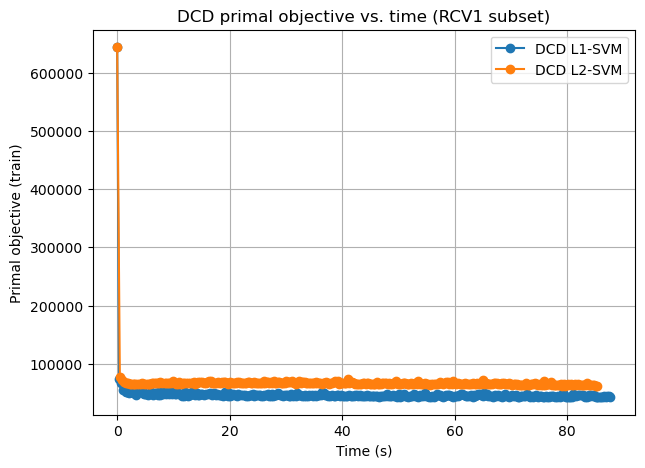

In [8]:
plt.figure(figsize=(7, 5))

if dcd_l1.obj_history_:
    plt.plot(dcd_l1.time_history_, dcd_l1.obj_history_, label="DCD L1-SVM", marker="o")
if dcd_l2.obj_history_:
    plt.plot(dcd_l2.time_history_, dcd_l2.obj_history_, label="DCD L2-SVM", marker="o")

plt.xlabel("Time (s)")
plt.ylabel("Primal objective (train)")
plt.title("DCD primal objective vs. time (RCV1 subset)")
plt.legend()
plt.grid(True)
plt.show()

## Reference optimal solution and relative error metric

To match the paper more closely, we first compute an approximate optimal solution `w_star` by running DCD for many epochs, then measure **relative error**
\\[ \text{rel\_err}(w) = \frac{|f_P(w) - f_P(w^*)|}{|f_P(w^*)|} \\]
versus time, rather than plotting raw objective values.

In [9]:
# Compute an approximate optimal solution w_star for L2-SVM
C_value = 1.0

ref_epochs = 3  # increase if you want a tighter optimum
ref_dcd_l2 = DCDSVM(C=C_value, loss="l2", epochs=ref_epochs, record_objective=False)
ref_dcd_l2.fit(X_train, y_train)

w_star_l2 = ref_dcd_l2.w
f_star_l2 = primal_objective(w_star_l2, X_train, y_train, C=C_value, loss="l2")

print("Reference DCD L2-SVM objective (f_star_l2):", f_star_l2)

Epoch: 1


/var/folders/j3/c1ymhtkd4gx28tsdpgsc1x140000gn/T/ipykernel_44533/3120286661.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G = y[i] * float(xi_sparse.dot(w)) - 1.0 + D[i] * alpha[i]


Epoch: 2
Epoch: 3
Reference DCD L2-SVM objective (f_star_l2): 46206.64227413493


In [10]:
def run_dcd_convergence_l2(C=1.0, max_epochs=3, tol=0.01):
    """Run DCD L2-SVM until relative error <= tol, tracking time and rel. error."""
    model = DCDSVM(C=C, loss="l2", epochs=1, record_objective=False)

    rel_errors = []
    times = []

    start = time.time()
    epoch = 0

    while epoch < max_epochs:
        epoch += 1
        model.fit(X_train, y_train)

        w = model.w
        primal = primal_objective(w, X_train, y_train, C=C, loss="l2")
        rel_err = abs(primal - f_star_l2) / abs(f_star_l2)

        rel_errors.append(rel_err)
        times.append(time.time() - start)

        print(f"Epoch {epoch}, primal={primal:.4f}, rel_err={rel_err:.3e}")
        if rel_err <= tol:
            break

    return model, np.array(times), np.array(rel_errors)

conv_dcd_l2, conv_times_l2, conv_rel_err_l2 = run_dcd_convergence_l2(C_value, max_epochs=3, tol=0.01)

Epoch: 1


/var/folders/j3/c1ymhtkd4gx28tsdpgsc1x140000gn/T/ipykernel_44533/3120286661.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G = y[i] * float(xi_sparse.dot(w)) - 1.0 + D[i] * alpha[i]


Epoch 1, primal=63522.0973, rel_err=3.747e-01
Epoch: 1
Epoch 2, primal=65283.7998, rel_err=4.129e-01
Epoch: 1
Epoch 3, primal=64187.4617, rel_err=3.891e-01


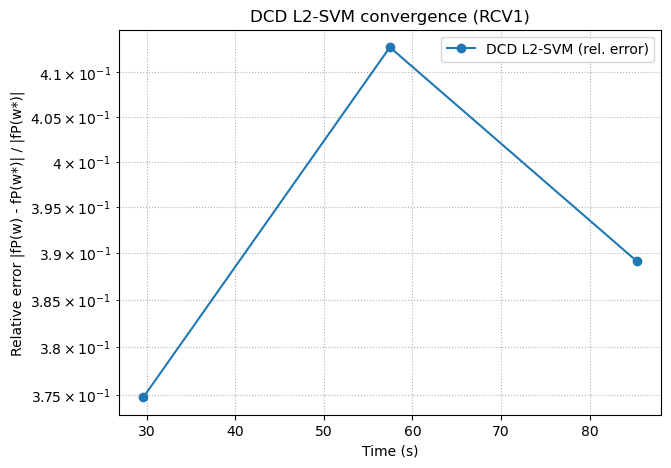

In [11]:
# Plot relative error vs time on a log scale (similar to Figure 1 in the paper)
plt.figure(figsize=(7, 5))

plt.semilogy(conv_times_l2, conv_rel_err_l2, marker="o", label="DCD L2-SVM (rel. error)")

plt.xlabel("Time (s)")
plt.ylabel("Relative error |fP(w) - fP(w*)| / |fP(w*)|")
plt.title("DCD L2-SVM convergence (RCV1)")
plt.legend()
plt.grid(True, which="both", linestyle=":")
plt.show()